<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_74952/278684481.py:34: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Eigenvalue $\lambda$ (Normalized $s^2/M$)', fontsize=12)


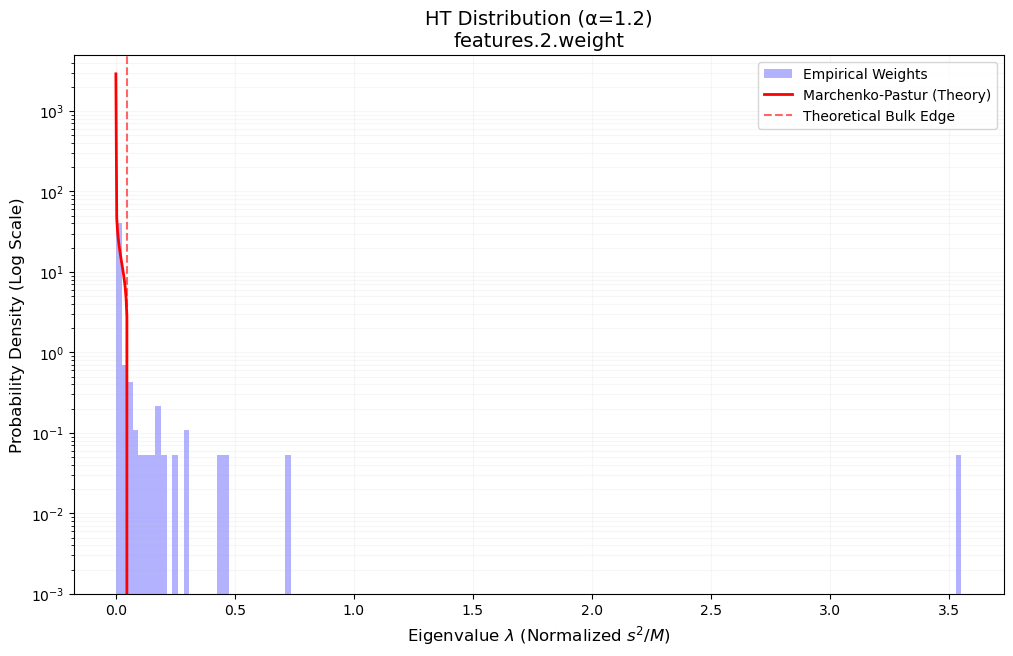

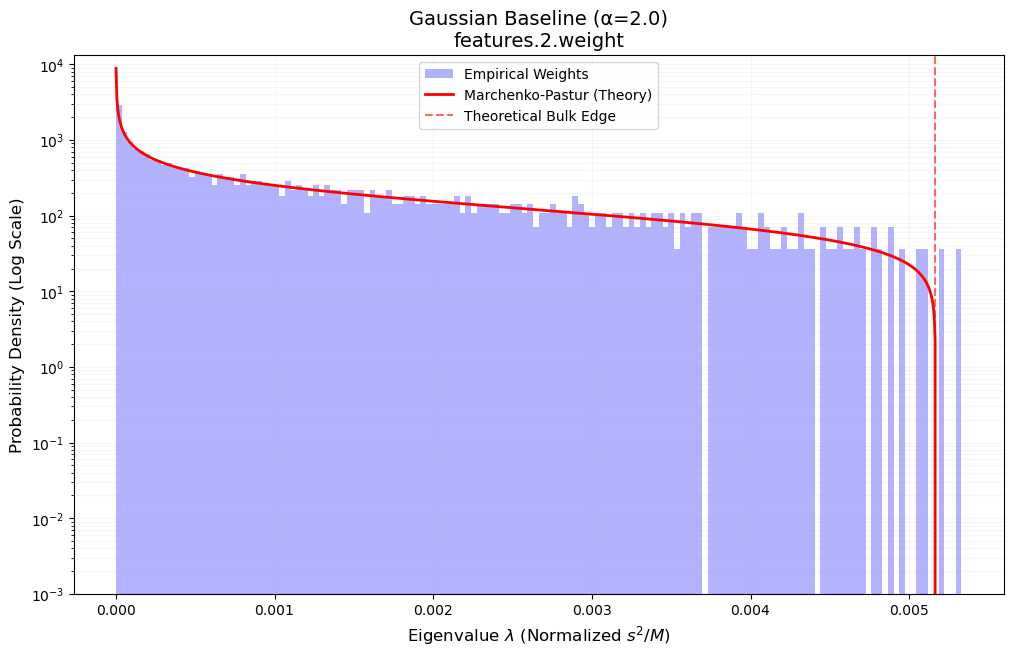

<Figure size 640x480 with 0 Axes>

HT Max Eigenvalue: 3.5530
Gaussian Max Eigenvalue: 0.0053


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from src import get_singular_values, plot_esd_with_theory, marchenko_pastur_pdf

def plot_esd_with_theory(eigenvalues, N, M, title="Empirical Spectral Density"):
    """
    Plots the histogram of eigenvalues against the MP Law.
    """
    Q = N / M
    # sigma_est is the variance of the entries, based on the mean eigenvalue
    sigma_est = np.sqrt(np.mean(eigenvalues))

    plt.figure(figsize=(12, 7))

    # 1. Use density=True for a proper probability distribution
    # We use a log-scale for the Y-axis to see the outliers and the bulk together
    counts, bins, _ = plt.hist(eigenvalues, bins=150, density=True,
                               alpha=0.3, color='blue', label='Empirical Weights')

    # 2. Theoretical MP Law
    x_range = np.linspace(max(1e-6, np.min(bins)), np.max(bins), 1000)
    pdf, l_min, l_max = marchenko_pastur_pdf(x_range, Q, sigma=sigma_est)

    plt.plot(x_range, pdf, 'r-', lw=2, label=f'Marchenko-Pastur (Theory)')

    # 3. Aesthetics & Scaling
    plt.yscale('log') # CRITICAL for Heavy-Tailed visualization
    plt.axvline(l_max, color='red', linestyle='--', alpha=0.6, label='Theoretical Bulk Edge')

    plt.title(title, fontsize=14)
    plt.xlabel('Eigenvalue $\lambda$ (Normalized $s^2/M$)', fontsize=12)
    plt.ylabel('Probability Density (Log Scale)', fontsize=12)
    plt.ylim(bottom=1e-3) # Clip the bottom so the log scale is readable
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.1)
    plt.show()

# 1. Setup paths to your successful runs
# Replace these with your actual folder names from the console output
HT_PATH = Path("training_runs/mlp_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260221_130323_s0")
GAUSS_PATH = Path("training_runs/mlp_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260221_130451_s0")

def load_weights(path):
    checkpoint = torch.load(path / "final_model.pth")
    return checkpoint['model_state']

# 2. Extract weights
ht_weights = load_weights(HT_PATH)
gauss_weights = load_weights(GAUSS_PATH)

# We'll focus on the first hidden layer: 'fc1.weight' (or similar in your GeneralMLP)
# Check ht_weights.keys() if you're unsure of the name
layer_key = 'features.2.weight' 

W_ht = ht_weights[layer_key]
W_ga = gauss_weights[layer_key]

# 3. Compute Normalized Eigenvalues
# Ensure your get_singular_values divides by M (columns)
evs_ht = get_singular_values(W_ht)
evs_ga = get_singular_values(W_ga)

# 4. Comparative Plotting
# Plot HT
N, M = W_ht.shape
plot_esd_with_theory(evs_ht, N, M, title=f"HT Distribution (α=1.2)\n{layer_key}")

# Plot Gaussian
N_g, M_g = W_ga.shape
plot_esd_with_theory(evs_ga, N_g, M_g, title=f"Gaussian Baseline (α=2.0)\n{layer_key}")

plt.tight_layout()
plt.show()

# 5. Numerical Outlier Check
print(f"HT Max Eigenvalue: {np.max(evs_ht):.4f}")
print(f"Gaussian Max Eigenvalue: {np.max(evs_ga):.4f}")

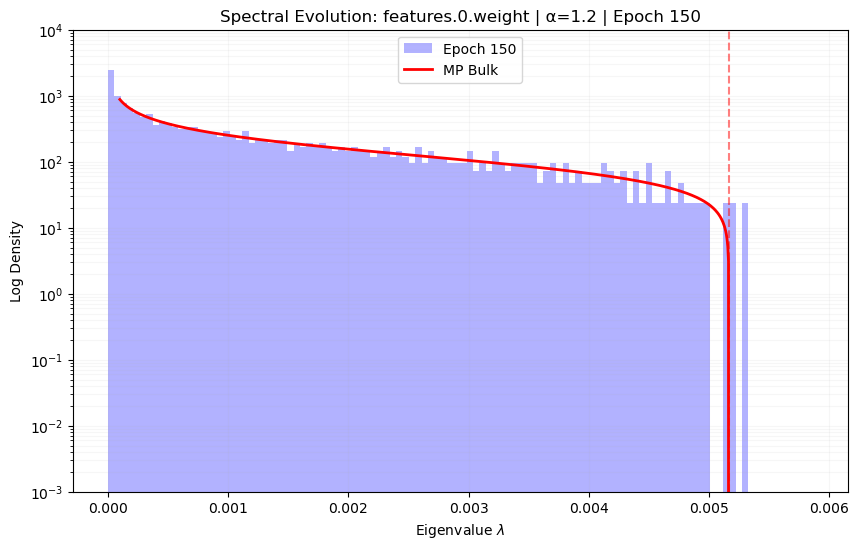

Relative Weight Displacement: 0.104798
Top Eigenvalue Shift: 0.000281


In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pathlib import Path
from src import get_singular_values, marchenko_pastur_pdf
from IPython.display import clear_output, display

# 1. Config
RUN_DIR = Path("training_runs/mlp_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260221_130451_s0")
LAYER_KEY = 'features.0.weight'
EPOCHS = range(0, 160, 10)  # Matches your saving frequency

def get_evs_from_epoch(epoch):
    path = RUN_DIR / "checkpoints" / f"weights_epoch_{epoch}.pth"
    state_dict = torch.load(path)
    weights = state_dict[LAYER_KEY]
    return get_singular_values(weights), weights.shape

# 2. Manual Loop for Notebooks
for epoch in EPOCHS:
    try:
        # Load weights
        path = RUN_DIR / "checkpoints" / f"weights_epoch_{epoch}.pth"
        if not path.exists():
            print(f"Skipping {epoch}: Path not found.")
            continue
            
        state_dict = torch.load(path)
        weights = state_dict[LAYER_KEY]
        evs = get_singular_values(weights)
        N, M = weights.shape
        Q = N / M
        
        # Plotting
        clear_output(wait=True) # Clears the previous plot for the "animation" effect
        plt.figure(figsize=(10, 6))
        
        # Empirical
        plt.hist(evs, bins=100, density=True, alpha=0.3, color='blue', label=f'Epoch {epoch}')
        
        # Theoretical MP
        sigma_est = np.sqrt(np.mean(evs))
        x_max_plot = np.max(evs) * 1.1
        x_range = np.linspace(1e-4, x_max_plot, 1000)
        pdf, _, l_max = marchenko_pastur_pdf(x_range, Q, sigma=sigma_est)
        
        plt.plot(x_range, pdf, 'r-', lw=2, label='MP Bulk')
        plt.axvline(l_max, color='red', linestyle='--', alpha=0.5)
        
        # Scaling
        plt.yscale('log')
        plt.ylim(1e-3, 1e4)
        plt.title(f"Spectral Evolution: {LAYER_KEY} | α=1.2 | Epoch {epoch}")
        plt.xlabel("Eigenvalue $\lambda$")
        plt.ylabel("Log Density")
        plt.legend()
        plt.grid(True, which='both', alpha=0.1)
        
        display(plt.gcf()) # Explicitly show the figure
        plt.close() # Close to free memory
        
    except Exception as e:
        print(f"Error at epoch {epoch}: {e}")

# Compare Epoch 0 to Epoch 150
W_init = torch.load(RUN_DIR / "checkpoints/weights_epoch_0.pth")[LAYER_KEY]
W_final = torch.load(RUN_DIR / "checkpoints/weights_epoch_150.pth")[LAYER_KEY]

# 1. Check weight displacement
dist = torch.norm(W_final - W_init) / torch.norm(W_init)
print(f"Relative Weight Displacement: {dist.item():.6f}")

# 2. Check the Top Outlier movement
evs_0 = get_singular_values(W_init)
evs_150 = get_singular_values(W_final)

shift = np.max(evs_150) - np.max(evs_0)
print(f"Top Eigenvalue Shift: {shift:.6f}")